In [1]:
# Import packages and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedGroupKFold

In [2]:
# Check the version of XGBoost
print("Found XGBoost v" + xgboost.__version__)

Found XGBoost v2.1.4


In [3]:
datasetPath = "dataset/100p/glcm/kernel5/"

In [4]:
# Parameters
datasetPath = "dataset/600p/glcm/kernel5/"


In [5]:
# train/validation/test = 70/10/20
train_data = pd.read_csv(f"{datasetPath}dataset.train.csv")
validation_data = pd.read_csv(f"{datasetPath}dataset.validation.csv")
test_data = pd.read_csv(f"{datasetPath}dataset.test.csv")

## 5-fold cross-validation at patient level

Cross-validation is performed only on the development set (**Train + Validation**). The independent **Test** set is not used during cross-validation or model selection. All voxels from the same patient are kept in the same fold by `StratifiedGroupKFold`.


In [6]:
# 5-fold patient-level cross-validation (Train + Validation only)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    confusion_matrix
)

# Detect the patient identifier column. Add another candidate here if your CSV uses a different name.
group_candidates = [
    "patient_id", "patient", "case_id", "case",
    "subject_id", "subject", "BraTS21ID", "brats_id"
]
group_col = next((c for c in group_candidates if c in train_data.columns), None)
if group_col is None:
    raise ValueError(
        "Patient ID column was not found. "
        "Set group_col manually to the column identifying each patient, "
        "for example: group_col = 'patient_id'."
    )

print(f"Patient/group column: {group_col}")

# IMPORTANT: keep the independent test set completely outside CV.
dev_data = pd.concat([train_data], ignore_index=True)

# Exclude labels, weights, and patient/case metadata from model features.
metadata_cols = set(group_candidates + ["label", "sample_weight"])
cv_feature_cols = [c for c in dev_data.columns if c not in metadata_cols]

X_dev = dev_data[cv_feature_cols]
y_dev = dev_data["label"].astype(int)
groups_dev = dev_data[group_col]

# Sanity check: no patient in development data may occur in the independent test set.
if group_col in test_data.columns:
    overlap = set(groups_dev.unique()) & set(test_data[group_col].unique())
    assert len(overlap) == 0, (
        f"Data leakage: {len(overlap)} patient(s) occur in both development and test sets: "
        f"{list(overlap)[:10]}"
    )

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_dev, y_dev, groups=groups_dev), start=1
):
    X_fold_train = X_dev.iloc[train_idx]
    y_fold_train = y_dev.iloc[train_idx]
    X_fold_val = X_dev.iloc[val_idx]
    y_fold_val = y_dev.iloc[val_idx]

    train_groups = set(groups_dev.iloc[train_idx])
    val_groups = set(groups_dev.iloc[val_idx])
    assert train_groups.isdisjoint(val_groups), f"Patient leakage in fold {fold}"

    # Compute class weights from this fold's training partition only.
    fold_classes = np.unique(y_fold_train)
    fold_weights = compute_class_weight(
        class_weight="balanced",
        classes=fold_classes,
        y=y_fold_train
    )
    fold_class_weight = dict(zip(fold_classes, fold_weights))
    fold_sample_weight = y_fold_train.map(fold_class_weight).to_numpy()

    cv_model = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric=["logloss", "auc"],
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )

    cv_model.fit(
        X_fold_train,
        y_fold_train,
        sample_weight=fold_sample_weight,
        verbose=False
    )

    fold_prob = cv_model.predict_proba(X_fold_val)[:, 1]
    fold_pred = (fold_prob >= 0.5).astype(int)

    cm = confusion_matrix(y_fold_val, fold_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    result = {
        "fold": fold,
        "train_patients": len(train_groups),
        "val_patients": len(val_groups),
        "train_voxels": len(train_idx),
        "val_voxels": len(val_idx),
        "accuracy": accuracy_score(y_fold_val, fold_pred),
        "precision": precision_score(y_fold_val, fold_pred, zero_division=0),
        "recall": recall_score(y_fold_val, fold_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_fold_val, fold_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_fold_val, fold_prob),
        "pr_auc": average_precision_score(y_fold_val, fold_prob),
        "mcc": matthews_corrcoef(y_fold_val, fold_pred),
    }
    fold_results.append(result)

    print(
        f"Fold {fold}: "
        f"patients(train/val)={len(train_groups)}/{len(val_groups)}, "
        f"AUC={result['roc_auc']:.4f}, F1={result['f1']:.4f}, "
        f"Recall={result['recall']:.4f}"
    )

cv_results = pd.DataFrame(fold_results)
display(cv_results)

metric_cols = [
    "accuracy", "precision", "recall", "specificity",
    "f1", "roc_auc", "pr_auc", "mcc"
]
cv_summary = pd.DataFrame({
    "mean": cv_results[metric_cols].mean(),
    "std": cv_results[metric_cols].std(ddof=1),
})

print("\n5-fold patient-level CV summary (mean ± SD):")
for metric in metric_cols:
    print(
        f"{metric:12s}: "
        f"{cv_summary.loc[metric, 'mean']:.4f} ± "
        f"{cv_summary.loc[metric, 'std']:.4f}"
    )

display(cv_summary)


Patient/group column: patient_id


Fold 1: patients(train/val)=480/120, AUC=0.9672, F1=0.5838, Recall=0.8855


Fold 2: patients(train/val)=481/119, AUC=0.9722, F1=0.5787, Recall=0.9208


Fold 3: patients(train/val)=480/120, AUC=0.9675, F1=0.5577, Recall=0.9015


Fold 4: patients(train/val)=480/120, AUC=0.9703, F1=0.6070, Recall=0.8857


Fold 5: patients(train/val)=479/121, AUC=0.9726, F1=0.6057, Recall=0.9073


,fold,train_patients,val_patients,train_voxels,val_voxels,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,mcc
0,1,480,120,543891,134774,0.919391,0.435389,0.885505,0.921702,0.583755,0.967249,0.786149,0.587085
1,2,481,119,542492,136173,0.912442,0.421910,0.920828,0.911856,0.578678,0.972245,0.806794,0.588470
2,3,480,120,543042,135623,0.907132,0.403752,0.901464,0.907526,0.557713,0.967459,0.793157,0.566194
3,4,480,120,543366,135299,0.930310,0.461699,0.885659,0.933199,0.606978,0.970279,0.800005,0.609612
4,5,479,121,541869,136796,0.923316,0.454581,0.907320,0.924427,0.605698,0.972606,0.813685,0.610203



5-fold patient-level CV summary (mean ± SD):
accuracy    : 0.9185 ± 0.0091
precision   : 0.4355 ± 0.0237
recall      : 0.9002 ± 0.0150
specificity : 0.9197 ± 0.0102
f1          : 0.5866 ± 0.0205
roc_auc     : 0.9700 ± 0.0025
pr_auc      : 0.8000 ± 0.0109
mcc         : 0.5923 ± 0.0183


,mean,std
accuracy,0.918518,0.009074
precision,0.435466,0.023681
recall,0.900155,0.015043
specificity,0.919742,0.010226
f1,0.586564,0.020526
roc_auc,0.969968,0.002546
pr_auc,0.799958,0.010864
mcc,0.592313,0.018327


In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights on the training set
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data["label"]
)
class_weight = dict(zip(classes, weights))

# Prepare features and sample weights for XGBoost
metadata_cols = {
    "label", "sample_weight", "patient_id", "patient", "case_id", "case",
    "subject_id", "subject", "BraTS21ID", "brats_id"
}
feature_cols = [
    col for col in train_data.columns
    if col not in metadata_cols
]
X_train = train_data[feature_cols]
y_train = train_data["label"].astype(int)
X_val = validation_data[feature_cols]
y_val = validation_data["label"].astype(int)
X_test = test_data[feature_cols]
y_test = test_data["label"].astype(int)

train_weight = y_train.map(class_weight).to_numpy()
val_weight = y_val.map(class_weight).to_numpy()
test_weight = y_test.map(class_weight).to_numpy()

In [8]:
# XGBClassifier uses the pandas data prepared above

In [9]:
%%time

# Train an XGBoost binary classification model.
model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric=["logloss", "auc"],
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    sample_weight=train_weight,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    sample_weight_eval_set=[train_weight, val_weight],
    verbose=False
)

CPU times: user 5min 45s, sys: 424 ms, total: 5min 45s
Wall time: 29 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [10]:
# Evaluate the model on the validation set
from sklearn.metrics import accuracy_score, roc_auc_score

val_probs = model.predict_proba(X_val)[:, 1]
val_pred = (val_probs >= 0.5).astype(int)

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Validation ROC AUC: {roc_auc_score(y_val, val_probs):.4f}")

Validation accuracy: 0.9149
Validation ROC AUC: 0.9782


In [11]:
# Model summary
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['logloss', 'auc'],
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)


In [12]:
# Model features
feature_cols

['Autocorrelation',
 'ClusterProminence',
 'ClusterShade',
 'ClusterTendency',
 'Contrast',
 'Correlation',
 'DifferenceAverage',
 'DifferenceEntropy',
 'DifferenceVariance',
 'Id',
 'Idm',
 'Idmn',
 'Idn',
 'Imc1',
 'Imc2',
 'InverseVariance',
 'JointAverage',
 'JointEnergy',
 'JointEntropy',
 'MCC',
 'MaximumProbability',
 'SumAverage',
 'SumEntropy',
 'SumSquares']

Correlation           0.181358
JointAverage          0.116139
DifferenceVariance    0.115724
SumAverage            0.074399
Autocorrelation       0.053232
Imc1                  0.046439
InverseVariance       0.045693
Idn                   0.041612
Contrast              0.040055
MaximumProbability    0.039160
DifferenceEntropy     0.036065
Idmn                  0.031137
ClusterShade          0.025929
DifferenceAverage     0.020827
MCC                   0.019869
Id                    0.019249
Idm                   0.017306
SumEntropy            0.017252
Imc2                  0.011435
SumSquares            0.011040
dtype: float32


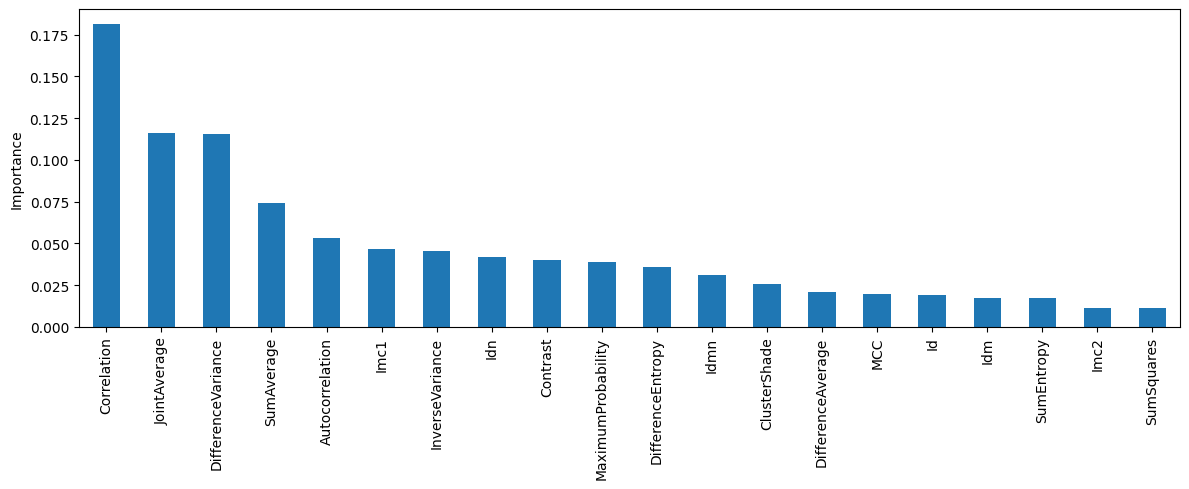

In [13]:
# Feature importance
feature_importance = (
    pd.Series(model.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

print(feature_importance.head(20))
feature_importance.head(20).plot.bar(figsize=(12, 5))
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [14]:
# Model attributes
model.get_booster().attributes()

{}

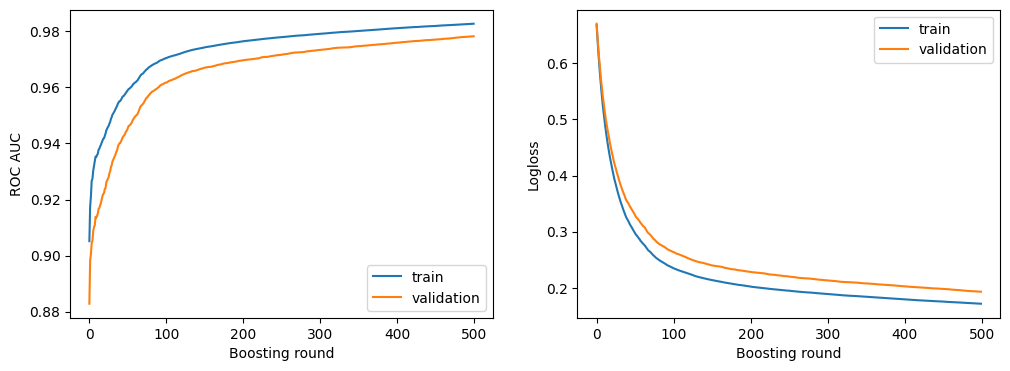

In [15]:
results = model.evals_result()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(results["validation_0"]["auc"], label="train")
plt.plot(results["validation_1"]["auc"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("ROC AUC")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="validation")
plt.xlabel("Boosting round")
plt.ylabel("Logloss")
plt.legend()
plt.show()

Calculate the score of our hold-out validation dataset

In [16]:
predictions = model.predict_proba(X_val)[:, 1]
y_true = y_val

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC)

The ROC AUC score is 0.97821


In [17]:
# Compute binary classification metrics with sklearn
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get positive-class probabilities and convert them to labels
pos_probs = model.predict_proba(X_test)[:, 1]
y_pred = (pos_probs >= 0.5).astype(int)
y_true = y_test.to_numpy()

metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0, 1])
metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

Sklearn binary metrics:
accuracy: 0.8242
precision: 0.2774
recall: 0.8887
f1: 0.4229
mcc: 0.4347
roc_auc: 0.9334
pr_auc: 0.7125
log_loss: 0.3907
brier_score: 0.1243

Confusion matrix:
 [[172627  38105]
 [  1832  14631]]

Classification report:
               precision    recall  f1-score   support

           0     0.9895    0.8192    0.8963    210732
           1     0.2774    0.8887    0.4229     16463

    accuracy                         0.8242    227195
   macro avg     0.6335    0.8539    0.6596    227195
weighted avg     0.9379    0.8242    0.8620    227195

